<a href="https://colab.research.google.com/github/Storm00212/SIGNALS-ASSIGNMENT-1/blob/main/QUESTION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ORIGINAL FOURIER TRANSFORMED RECTANGULAR PULSE

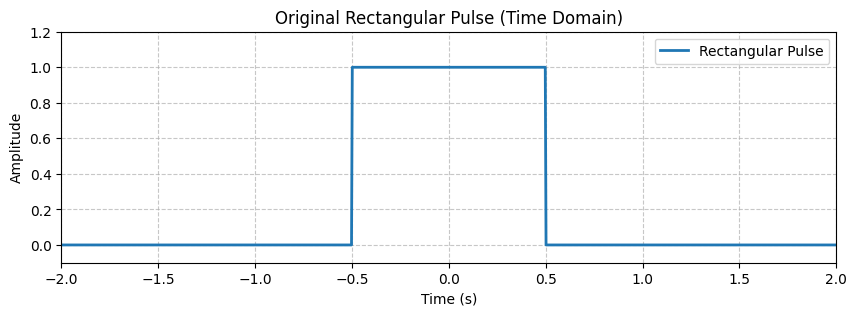

In [63]:
# I first showed it in time domain before doing a fourier transform.
samplings = 500
duration = 4
sampling_rate = int(samplings* duration)
t = np.linspace(-duration/2, duration/2, sampling_rate, endpoint=False)
rect_pulse_p = np.heaviside(t+0.5, 0.5) - np.heaviside(t - 0.5, 0.5)
plt.figure(figsize=(10, 3))
plt.plot(t, rect_pulse_p, label="Rectangular Pulse", linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Original Rectangular Pulse (Time Domain)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-2, 2)
plt.ylim(-0.1, 1.2)
plt.legend()
plt.show()


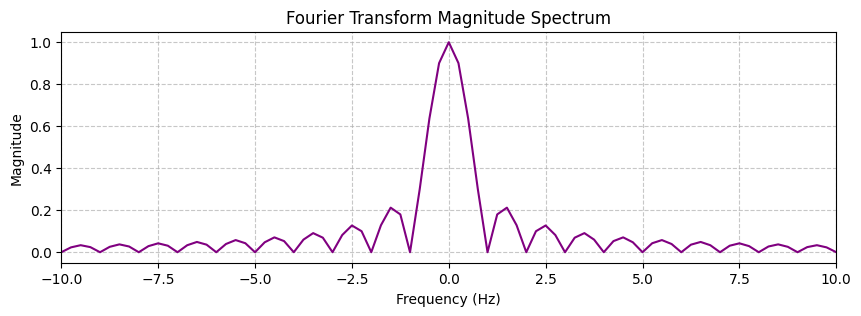

In [64]:
# now its fourier transform

frequencies = np.fft.fftfreq(sampling_rate, d = 1/samplings)
fourier_rect_pulse = np.fft.fft(rect_pulse_p)

#plt.plot(frequencies, np.abs(fourier_rect_pulse))
# note: after doing fft you also have to use fft shift other wise +ve and -ve sides will overlap showing a bad graph
freq_shifted = np.fft.fftshift(frequencies)
fourier_shifted = np.fft.fftshift(fourier_rect_pulse)

plt.figure(figsize=(10, 3)) # large figsize to visualise
plt.plot(freq_shifted, np.abs(fourier_shifted) / samplings, color='purple', linewidth=1.5)#divided by samplings for normalisation.
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Fourier Transform Magnitude Spectrum')
plt.xlim(-10, 10)  # Zoom in on main and first few side lobes
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# NOW WE APPLY THE BANDWIDTHS

0.5 BANDWIDTH

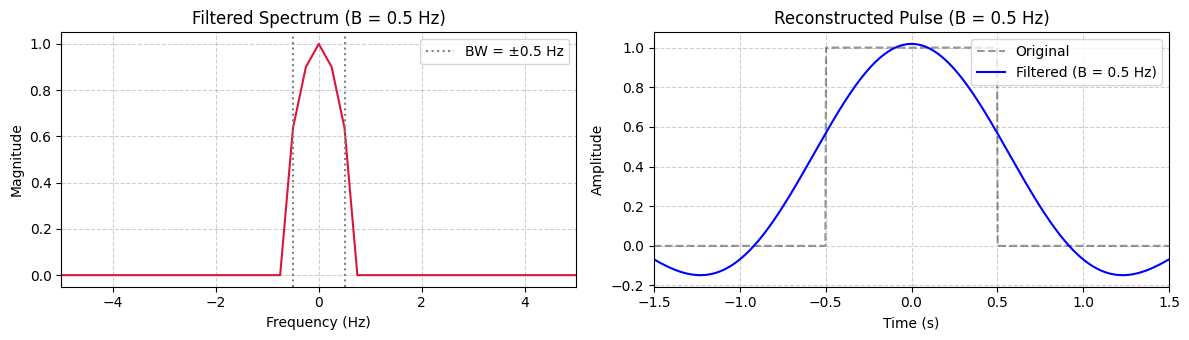

In [59]:
#B = np.heaviside(frequencies + 0.5, 1) - np.heaviside(frequencies - 0.5, 1)
#signal1 = B*fourier_rect_pulse
#plt.plot(frequencies, np.abs(signal1))
# plt.show()

B = 0.5

# 1. Low-Pass Filter
mask = (np.abs(freq_shifted) <= B).astype(float)# you can akso still use heaviside function
filtered_fourier_shifted = fourier_shifted * mask

# 2. Inverse FFT to get time-domain reconstructed signal
filtered_fourier = np.fft.ifftshift(filtered_fourier_shifted)
reconstructed_signal = np.real(np.fft.ifft(filtered_fourier))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Frequency Spectrum Plot
axes[0].plot(freq_shifted, np.abs(filtered_fourier_shifted) / samplings, color='crimson')
axes[0].axvline(x=-B, color='gray', linestyle=':', label=f'BW = ±{B} Hz')
axes[0].axvline(x=B, color='gray', linestyle=':')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title(f'Filtered Spectrum (B = {B} Hz)')
axes[0].set_xlim(-5, 5)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Time Domain Reconstructed Signal
axes[1].plot(t, rect_pulse_p, 'k--', alpha=0.4, label='Original')
axes[1].plot(t, reconstructed_signal, color='blue', label=f'Filtered (B = {B} Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Reconstructed Pulse (B = {B} Hz)')
axes[1].set_xlim(-1.5, 1.5)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

1 BANDWIDTH

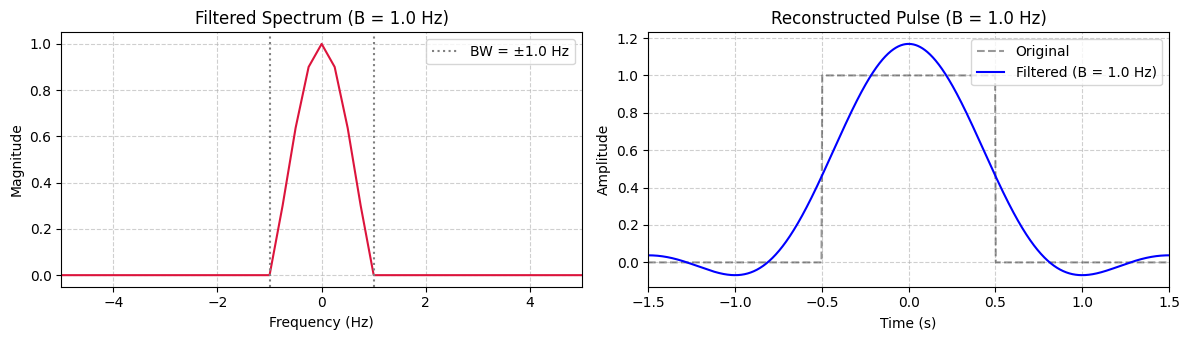

In [60]:
# B = np.heaviside(frequencies + 1, 0.5) - np.heaviside(frequencies - 1, 0.5)
# signal1 = B*fourier_rect_pulse
# plt.plot(frequencies, np.abs(signal1))
# plt.show()
B = 1.0

# 1. Low-Pass Filter
mask = (np.abs(freq_shifted) <= B).astype(float)
filtered_fourier_shifted = fourier_shifted * mask

# 2. Inverse FFT to get time-domain reconstructed signal
filtered_fourier = np.fft.ifftshift(filtered_fourier_shifted)
reconstructed_signal = np.real(np.fft.ifft(filtered_fourier))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Frequency  Plot
axes[0].plot(freq_shifted, np.abs(filtered_fourier_shifted) / samplings, color='crimson')
axes[0].axvline(x=-B, color='gray', linestyle=':', label=f'BW = ±{B} Hz')
axes[0].axvline(x=B, color='gray', linestyle=':')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title(f'Filtered Spectrum (B = {B} Hz)')
axes[0].set_xlim(-5, 5)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Time Domain Reconstructed Signalto compare
axes[1].plot(t, rect_pulse_p, 'k--', alpha=0.4, label='Original')
axes[1].plot(t, reconstructed_signal, color='blue', label=f'Filtered (B = {B} Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Reconstructed Pulse (B = {B} Hz)')
axes[1].set_xlim(-1.5, 1.5)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

2 BANDWIDTH

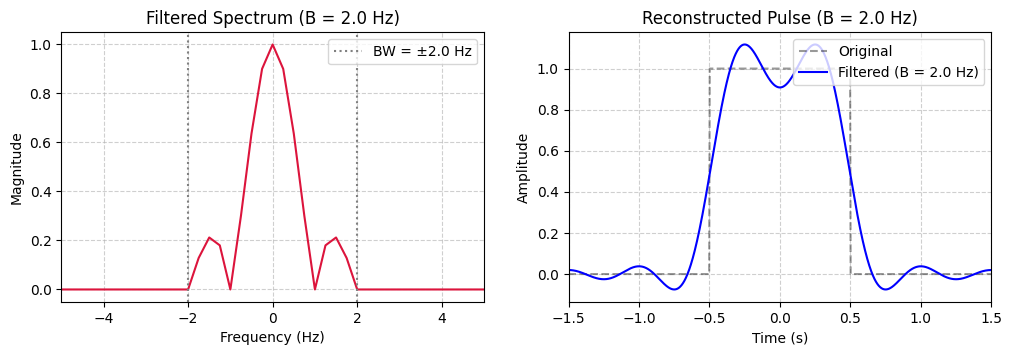

In [62]:
# B = np.heaviside(frequencies + 2, 0.5) - np.heaviside(frequencies - 2, 0.5)
# signal1 = B*fourier_rect_pulse
# plt.plot(frequencies, np.abs(signal1))
# plt.show()
B = 2.0
# low pass filter
mask=(np.abs(freq_shifted)<=B).astype(float)# use abs to get sinc wave.
filtered_fourier_shifted=fourier_shifted*mask
# getting back t domain shift reconstructed signal
filtered_fourier=np.fft.ifftshift(filtered_fourier_shifted)
reconstructed_signal=np.real(np.fft.ifft(filtered_fourier))
#plot
fig, axes = plt.subplots(1, 2, figsize=(12,3.5))
#frequency
axes[0].plot(freq_shifted, np.abs(filtered_fourier_shifted) / samplings, color='crimson')
axes[0].axvline(x=-B, color='gray', linestyle=':', label=f'BW = ±{B} Hz')
axes[0].axvline(x=B, color='gray', linestyle=':')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title(f'Filtered Spectrum (B = {B} Hz)')
axes[0].set_xlim(-5, 5)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()
#time-original rectangular pulse and reconstructed signal
axes[1].plot(t, rect_pulse_p, 'k--', alpha=0.4, label='Original')
axes[1].plot(t, reconstructed_signal, color='blue', label=f'Filtered (B = {B} Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Reconstructed Pulse (B = {B} Hz)')
axes[1].set_xlim(-1.5, 1.5)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

# FROM THIS IT IS CLEAR THAT THE MORE THE BANDWIDTH INCREASES THE CLOSER WE GET TO THE ORIGINAL SIGNAL IN T DOMAIN

# THIS IS BECAUSE HIGHER FREQUENCIES BECOME ACCOUNTED FOR, SO FOR AN ACCURATE RECONSTRUCION OF THE SIGNAL A HIGHER BANDWIDTH IS REQUIRED BY THE LOWPASS FILTER